In [1]:
import sys, os

# 현재 노트북 위치 기준으로 상위 경로(src 있는 곳) 추가
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(project_root)

# 확인
print("✅ sys.path 추가 완료:", project_root)

from src.data_loader import get_dataloader, sanity_check_sample


✅ sys.path 추가 완료: /home/mingyeong/GAL2DM_ASIM_VNET


In [2]:
# ======================================================
# 🔍 data_loader.py 간단 디버그 테스트 (Jupyter)
# ======================================================
import os
#import torch
import numpy as np

# 1️⃣ 모듈 import
from src.data_loader import get_dataloader, sanity_check_sample

# 2️⃣ YAML 파일 경로 설정
yaml_path = "/home/mingyeong/GAL2DM_ASIM_VNET/etc/aims_paths.yml"


In [5]:
# ===========================================
# A-SIM HDF5 Dataset Summary Script
# ===========================================
import os
import yaml
import h5py
import numpy as np
from glob import glob

# -------------------------------------------
# 1. YAML 파일 경로 지정
# -------------------------------------------
yaml_path = "/home/mingyeong/GAL2DM_ASIM_VNET/etc/asim_paths.yaml"

# -------------------------------------------
# 2. YAML 로드
# -------------------------------------------
with open(yaml_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

base_dir = cfg["asim_datasets_hdf5"]["base_path"]
train_pattern = os.path.join(base_dir, cfg["asim_datasets_hdf5"]["training_set"]["path"])
val_pattern   = os.path.join(base_dir, cfg["asim_datasets_hdf5"]["validation_set"]["path"])

train_files = sorted(glob(train_pattern))
val_files   = sorted(glob(val_pattern))

print(f"🟢 Training files: {len(train_files)}")
print(f"🟣 Validation/Test files: {len(val_files)}\n")

# -------------------------------------------
# 3. HDF5 파일 내부 구조 탐색 함수
# -------------------------------------------
def summarize_hdf5(filepath, max_show=3):
    with h5py.File(filepath, "r") as f:
        print(f"📁 File: {os.path.basename(filepath)}")
        print(f"   Keys: {list(f.keys())}")

        for key in f.keys():
            dset = f[key]
            print(f"   ├─ {key:<15} shape={dset.shape} dtype={dset.dtype}")
            if isinstance(dset[0], np.ndarray) or dset.ndim > 1:
                sample_val = np.array(dset)
                print(f"   │    min={sample_val.min():.4g}, max={sample_val.max():.4g}, mean={sample_val.mean():.4g}")
        print()

# -------------------------------------------
# 4. 일부 샘플 파일에 대해 구조 출력
# -------------------------------------------
n_sample = min(3, len(train_files))
print(f"🔍 Example Training Files (showing {n_sample}):\n")
for fp in train_files[:n_sample]:
    summarize_hdf5(fp)

n_sample = min(3, len(val_files))
print(f"🔍 Example Validation/Test Files (showing {n_sample}):\n")
for fp in val_files[:n_sample]:
    summarize_hdf5(fp)

# -------------------------------------------
# 5. 전체 데이터셋 요약
# -------------------------------------------
total_files = len(train_files) + len(val_files)
print("📊 Dataset Summary")
print("--------------------")
print(f"Total HDF5 files : {total_files}")
print(f" - Training set  : {len(train_files)} files")
print(f" - Validation/Test set : {len(val_files)} files")

# 각 파일의 크기 (MB)
sizes = [os.path.getsize(f) / 1024**2 for f in train_files + val_files]
print(f"Average file size : {np.mean(sizes):.2f} MB")
print(f"Total size approx : {np.sum(sizes):.1f} MB")


🟢 Training files: 0
🟣 Validation/Test files: 0

🔍 Example Training Files (showing 0):

🔍 Example Validation/Test Files (showing 0):

📊 Dataset Summary
--------------------
Total HDF5 files : 0
 - Training set  : 0 files
 - Validation/Test set : 0 files
Average file size : nan MB
Total size approx : 0.0 MB


/home/mingyeong/miniconda3/envs/torch/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/mingyeong/miniconda3/envs/torch/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


HDF5: /gpfs/adupuy/cosmicweb_asim/ASIM_TSC/samples/training/610.hdf5
NPY density: /gpfs/adupuy/cosmicweb_asim/ASIM_TSC/samples/predictions/test_0_final_mode0_lr_min1e-07_max1e-05_200epochs_rho_240712_a100_cmb_f2.5.npy
NPY potential: /gpfs/adupuy/cosmicweb_asim/ASIM_TSC/samples/predictions/test_0_final_mode0_lr_min1e-07_max1e-05_200epochs_tscphi_240717_a100_cmb.npy


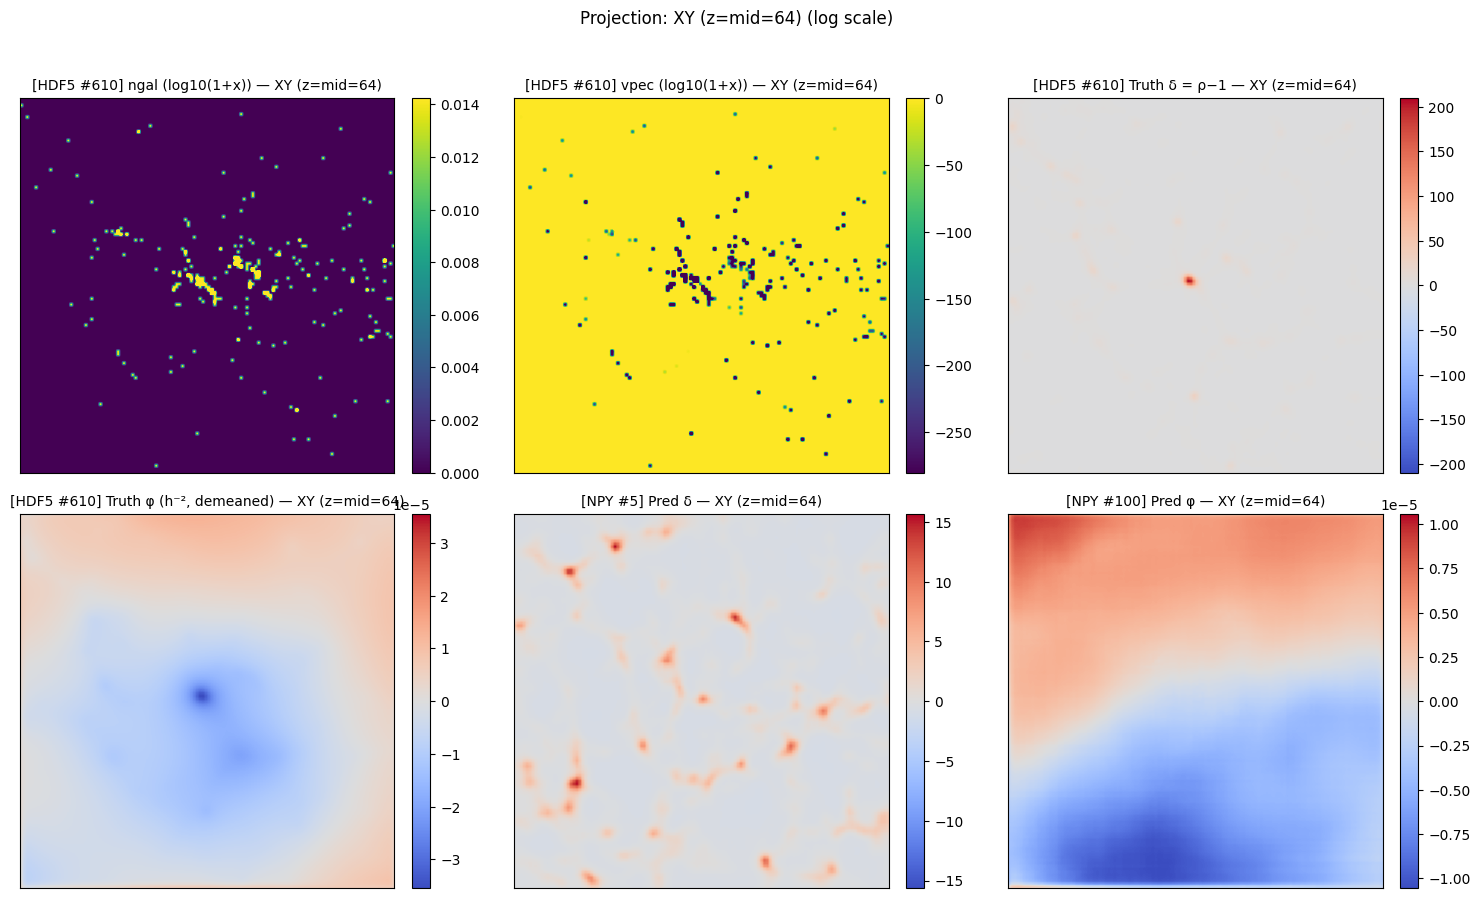

In [10]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os, re, yaml, h5py, numpy as np, matplotlib.pyplot as plt
from glob import glob

yaml_path = "/home/mingyeong/GAL2DM_ASIM_VNET/etc/asim_paths.yaml"
H = 0.72
H_INV2 = H ** (-2)

# --------------------------
# Config
# --------------------------
LOGSCALE = True   # 🔹 True → log10(1+x) 변환 적용

# --------------------------
# Utils
# --------------------------
def normalize_input_2ch(x):
    a = np.asarray(x)
    while a.ndim > 4 and a.shape[0] == 1:
        a = a[0]
    if a.ndim == 4 and a.shape[0] == 2: return a
    if a.ndim == 4 and a.shape[-1] == 2: return a.transpose(3,0,1,2)
    if a.ndim == 5 and a.shape[0] == 1 and a.shape[1] == 2: return a[0]
    a_s = np.squeeze(a)
    if a_s.ndim == 4 and a_s.shape[0] == 2: return a_s
    if a_s.ndim == 4 and a_s.shape[-1] == 2: return a_s.transpose(3,0,1,2)
    raise AssertionError(f"input shape={a.shape}, squeeze→{a_s.shape}")

def normalize_scalar_3d(arr):
    a = np.asarray(arr); a_s = np.squeeze(a)
    if a_s.ndim == 4:
        if a_s.shape[0] == 1: a_s = a_s[0]
        elif a_s.shape[-1] == 1: a_s = a_s[...,0]
    if a_s.ndim != 3:
        raise AssertionError(f"3D 필요: raw={a.shape}, squeeze→{a_s.shape}")
    return a_s

def robust_vminmax(arr, lo=1, hi=99):
    vmin = np.percentile(arr, lo); vmax = np.percentile(arr, hi)
    if vmin == vmax: vmin, vmax = float(arr.min()), float(arr.max())
    return vmin, vmax

def center_slice(vol3d, axis=0):
    idx = vol3d.shape[axis] // 2
    if axis == 0: return vol3d[idx,:,:], idx
    elif axis == 1: return vol3d[:,idx,:], idx
    else: return vol3d[:,:,idx], idx

def show_img(ax, img, title, cmap="viridis", vmin=None, vmax=None, add_colorbar=True):
    im = ax.imshow(img, origin="lower", cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_title(title, fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    if add_colorbar: plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

def file_id_from_path(path):
    base = os.path.basename(path)
    nums = re.findall(r'\d+', base)
    return nums[-1] if nums else base

def proj_label(axis, mid_idx):
    return {0: f"YZ (x=mid={mid_idx})",
            1: f"XZ (y=mid={mid_idx})",
            2: f"XY (z=mid={mid_idx})"}[axis]

# --------------------------
# Load YAML & select files
# --------------------------
with open(yaml_path, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

hdf5_base = cfg["asim_datasets_hdf5"]["base_path"]
train_glob = os.path.join(hdf5_base, cfg["asim_datasets_hdf5"]["training_set"]["path"])
val_glob   = os.path.join(hdf5_base, cfg["asim_datasets_hdf5"]["validation_set"]["path"])
train_list = sorted(glob(train_glob)); val_list = sorted(glob(val_glob))
if not train_list and not val_list:
    raise FileNotFoundError("훈련/검증 HDF5 파일을 찾을 수 없습니다.")

#hdf5_file = (train_list + val_list)[0]
#hdf5_id = file_id_from_path(hdf5_file)
hdf5_file = os.path.join(hdf5_base, "training/610.hdf5")
hdf5_id = "610"

npy_base = cfg["asim_predictions_npy"]["base_path"]
rho_tpl  = cfg["asim_predictions_npy"]["density_reconstructions"]["path_template"]
phi_tpl  = cfg["asim_predictions_npy"]["potential_reconstructions"]["path_template"]
rho_list = sorted(glob(os.path.join(npy_base, rho_tpl)))
phi_list = sorted(glob(os.path.join(npy_base, phi_tpl)))
npy_file_rho = rho_list[0] if rho_list else None
npy_file_phi = phi_list[0] if phi_list else None
npy_rho_id = file_id_from_path(npy_file_rho) if npy_file_rho else None
npy_phi_id = file_id_from_path(npy_file_phi) if npy_file_phi else None

print("HDF5:", hdf5_file)
print("NPY density:", npy_file_rho)
print("NPY potential:", npy_file_phi)

# --------------------------
# Read HDF5
# --------------------------
with h5py.File(hdf5_file, "r") as f:
    x = normalize_input_2ch(f["input"][:])
    ngal, vpec = x[0], x[1]
    rho_t = normalize_scalar_3d(f["output_rho"][:])
    delta_true = rho_t - 1.0
    phi_true = None
    if "output_tscphi" in f:
        phi_t = normalize_scalar_3d(f["output_tscphi"][:])
        phi_true = phi_t * H_INV2
        phi_true -= phi_true.mean()

# --------------------------
# Read NPY predictions
# --------------------------
delta_pred = None; phi_pred = None
if npy_file_rho and os.path.exists(npy_file_rho):
    y_rho_p = normalize_scalar_3d(np.load(npy_file_rho))
    rho_pred = np.power(10.0, 2.5 * y_rho_p).astype(np.float32)
    delta_pred = rho_pred - 1.0

if npy_file_phi and os.path.exists(npy_file_phi):
    y_phi_p = normalize_scalar_3d(np.load(npy_file_phi))
    phi_pred = (y_phi_p / 8e4) * H_INV2
    phi_pred -= phi_pred.mean()

# --------------------------
# Visualization (log scale 적용)
# --------------------------
SLICE_AXIS = 2  # XY(z=mid)
proj_txt = proj_label(SLICE_AXIS, 64)

def logmap(x):
    """양수 배열 log10(1+x)"""
    return np.log10(1.0 + np.maximum(x, 0))

def maybe_log(arr):
    if not LOGSCALE: return arr
    if np.any(arr < 0):  # 음수 포함 → 그대로
        return arr
    return logmap(arr)

ngal_c, _ = center_slice(maybe_log(ngal), axis=SLICE_AXIS)
vpec_c, _ = center_slice(maybe_log(vpec), axis=SLICE_AXIS)
delta_c, _ = center_slice(delta_true, axis=SLICE_AXIS)
phi_c = center_slice(phi_true, axis=SLICE_AXIS)[0] if phi_true is not None else None
delta_pC = center_slice(delta_pred, axis=SLICE_AXIS)[0] if delta_pred is not None else None
phi_pC = center_slice(phi_pred, axis=SLICE_AXIS)[0] if phi_pred is not None else None

vmin_ng, vmax_ng = robust_vminmax(ngal_c)
vmin_vp, vmax_vp = robust_vminmax(vpec_c)
vabs_d = np.nanmax(np.abs(delta_c)) if delta_c is not None else None
vabs_phi = np.nanmax(np.abs(phi_c)) if phi_c is not None else None
vabs_dp = np.nanmax(np.abs(delta_pC)) if delta_pC is not None else None
vabs_phiP = np.nanmax(np.abs(phi_pC)) if phi_pC is not None else None

titles, images, cmaps, vmins, vmaxs = [], [], [], [], []
# Inputs
titles += [f"[HDF5 #{hdf5_id}] ngal {'(log10(1+x))' if LOGSCALE else ''} — {proj_txt}",
           f"[HDF5 #{hdf5_id}] vpec {'(log10(1+x))' if LOGSCALE else ''} — {proj_txt}"]
images += [ngal_c, vpec_c]
cmaps += ["viridis","viridis"]
vmins += [vmin_ng, vmin_vp]
vmaxs += [vmax_ng, vmax_vp]

# Truth
titles += [f"[HDF5 #{hdf5_id}] Truth δ = ρ−1 — {proj_txt}"]
images += [delta_c]
cmaps += ["coolwarm"]
vmins += [-vabs_d]; vmaxs += [vabs_d]
if phi_c is not None:
    titles += [f"[HDF5 #{hdf5_id}] Truth φ (h⁻², demeaned) — {proj_txt}"]
    images += [phi_c]; cmaps += ["coolwarm"]
    vmins += [-vabs_phi]; vmaxs += [vabs_phi]

# Predictions
if delta_pC is not None:
    titles += [f"[NPY #{npy_rho_id}] Pred δ — {proj_txt}"]
    images += [delta_pC]; cmaps += ["coolwarm"]
    vmins += [-vabs_dp]; vmaxs += [vabs_dp]
if phi_pC is not None:
    titles += [f"[NPY #{npy_phi_id}] Pred φ — {proj_txt}"]
    images += [phi_pC]; cmaps += ["coolwarm"]
    vmins += [-vabs_phiP]; vmaxs += [vabs_phiP]

n = len(images)
cols = 3; rows = int(np.ceil(n/cols))
plt.figure(figsize=(5*cols, 4.5*rows))
plt.suptitle(f"Projection: {proj_txt} {'(log scale)' if LOGSCALE else ''}", fontsize=12, y=0.995)

for i,(img,title,cmap,vmin,vmax) in enumerate(zip(images,titles,cmaps,vmins,vmaxs),start=1):
    ax = plt.subplot(rows,cols,i)
    show_img(ax,img,title,cmap,vmin,vmax,add_colorbar=True)

plt.tight_layout(rect=[0,0,1,0.97])
plt.show()


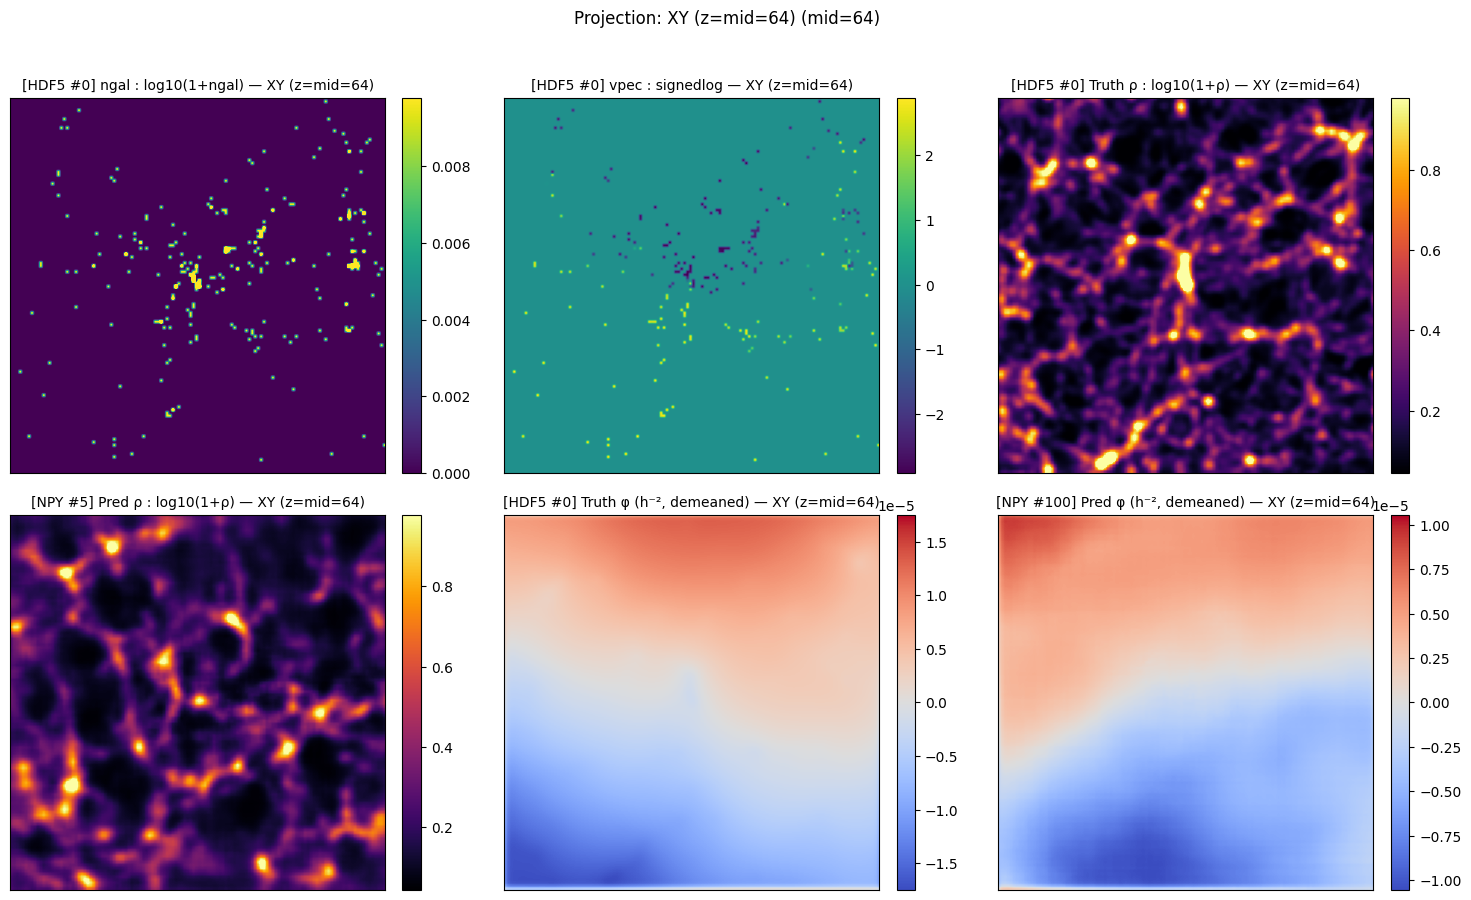

In [ ]:
# --------------------------
# Visualization: log10(1+ρ) + Inputs(ngal, vpec)
# --------------------------
SLICE_AXIS = 2  # XY(z=mid)
rho_true_c, mid_idx = center_slice(rho_t, axis=SLICE_AXIS)
rho_pred_c = center_slice(rho_pred, axis=SLICE_AXIS)[0] if rho_pred is not None else None
phi_c      = center_slice(phi_true, axis=SLICE_AXIS)[0] if phi_true is not None else None

# === Inputs (re-added) ===
ngal_c = center_slice(ngal, axis=SLICE_AXIS)[0]      # ngal ≥ 0 가정
VPEC_MODE = "signedlog"  # "signedlog" | "zscore"

def vpec_transform(a, mode="signedlog"):
    if mode == "signedlog":
        return np.sign(a) * np.log10(1.0 + np.abs(a))
    elif mode == "zscore":
        mu, sigma = float(np.mean(a)), float(np.std(a) + 1e-12)
        return (a - mu) / sigma
    else:
        return a

vpec_c = vpec_transform(center_slice(vpec, axis=SLICE_AXIS)[0], mode=VPEC_MODE)

# 로그 변환 (ρ만)
def log1p10_rho(rho):
    if np.any(rho < 0): raise ValueError("ρ는 음수가 아니어야 함")
    return np.log10(1.0 + rho)

log_rho_true = log1p10_rho(rho_true_c)
log_rho_pred = log1p10_rho(rho_pred_c) if rho_pred_c is not None else None

# 스케일: 진리 로그의 1–99%로 고정
vmin_rho, vmax_rho = robust_vminmax(log_rho_true)
vmin_ng, vmax_ng   = robust_vminmax(np.log10(1.0 + ngal_c))
vmin_vp, vmax_vp   = robust_vminmax(vpec_c)
vabs_phi = np.nanmax(np.abs(phi_c)) if phi_c is not None else None

proj_txt = proj_label(SLICE_AXIS, mid_idx)

titles, images, cmaps, vmins, vmaxs = [], [], [], [], []

# --- Inputs ---
titles += [f"[HDF5 #{hdf5_id}] ngal : log10(1+ngal) — {proj_txt}",
           f"[HDF5 #{hdf5_id}] vpec : {VPEC_MODE} — {proj_txt}"]
images += [np.log10(1.0 + ngal_c), vpec_c]
cmaps  += ["viridis", "viridis"]
vmins  += [vmin_ng, vmin_vp]
vmaxs  += [vmax_ng, vmax_vp]

# --- Truth ρ ---
titles += [f"[HDF5 #{hdf5_id}] Truth ρ : log10(1+ρ) — {proj_txt}"]
images += [log_rho_true]
cmaps  += ["inferno"]
vmins  += [vmin_rho]; vmaxs += [vmax_rho]

# --- Pred ρ ---
if log_rho_pred is not None:
    titles += [f"[NPY #{npy_rho_id}] Pred ρ : log10(1+ρ) — {proj_txt}"]
    images += [log_rho_pred]
    cmaps  += ["inferno"]
    vmins  += [vmin_rho]; vmaxs += [vmax_rho]

# --- φ (선형) ---
if phi_c is not None:
    titles += [f"[HDF5 #{hdf5_id}] Truth φ (h⁻², demeaned) — {proj_txt}"]
    images += [phi_c]; cmaps += ["coolwarm"]
    vmins  += [-vabs_phi]; vmaxs += [vabs_phi]

if phi_pred is not None:
    phi_pC = center_slice(phi_pred, axis=SLICE_AXIS)[0]
    vabs_phiP = np.nanmax(np.abs(phi_pC))
    titles += [f"[NPY #{npy_phi_id}] Pred φ (h⁻², demeaned) — {proj_txt}"]
    images += [phi_pC]; cmaps += ["coolwarm"]
    vmins  += [-vabs_phiP]; vmaxs += [vabs_phiP]

# --- draw ---
n = len(images); cols = 3; rows = int(np.ceil(n/cols)) if n>0 else 1
plt.figure(figsize=(5*cols, 4.5*rows))
plt.suptitle(f"Projection: {proj_txt} (mid={mid_idx})", fontsize=12, y=0.995)
for i,(img,title,cmap,vmin,vmax) in enumerate(zip(images,titles,cmaps,vmins,vmaxs),start=1):
    ax = plt.subplot(rows,cols,i)
    show_img(ax,img,title,cmap,vmin,vmax,add_colorbar=True)
plt.tight_layout(rect=[0,0,1,0.97]); plt.show()
